Capstone Two: Data Wrangling – Loan Default Risk Prediction

1. Introduction

This notebook documents the full data wrangling process for the Loan Default Risk Prediction project. The goal is to clean, structure, and prepare the dataset for exploratory data analysis and machine learning modeling.

We focus on:

Data loading and inspection
Data cleaning and transformation
Handling missing values
Treating outliers
Removing irrelevant or leaky features
Preparing a final clean dataset

In [2]:
## 2. Import Libraries

import pandas as pd
import numpy as np
import os

In [3]:
## 3. Load Dataset

df = pd.read_csv(r"C:\Users\samee\Desktop\accepted_2007_to_2018Q4.csv", nrows=100000, low_memory=False)

In [3]:
df.shape

(100000, 151)

In [4]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
## 4. Data Understanding (Data Definition)

print("Rows and Columns:", df.shape)

Rows and Columns: (100000, 151)


In [6]:
df.dtypes

id                         int64
member_id                float64
loan_amnt                float64
funded_amnt              float64
funded_amnt_inv          float64
                          ...   
settlement_status         object
settlement_date           object
settlement_amount        float64
settlement_percentage    float64
settlement_term          float64
Length: 151, dtype: object

In [7]:
df.isnull().sum().sort_values(ascending=False)

sec_app_open_act_il         100000
member_id                   100000
revol_bal_joint             100000
sec_app_fico_range_low      100000
sec_app_fico_range_high     100000
                             ...  
mo_sin_rcnt_rev_tl_op            0
mo_sin_old_rev_tl_op             0
delinq_amnt                      0
chargeoff_within_12_mths         0
id                               0
Length: 151, dtype: int64

Observations
Some columns contain high missing values
Several categorical and numeric variables exist
Some features may not be useful for modeling (potential leakage or redundancy)

In [8]:
## 5. Data Cleaning
## 5.1 Handling Missing Values

num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [9]:
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [10]:
## 5.2 Removing Duplicates

df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
## 5.3 Removing Irrelevant / Leaky Features

df.drop(columns=[
    "id",
    "url",
    "member_id"  # example placeholders
], inplace=True, errors="ignore")

In [12]:
## 6. Handling Outliers

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [13]:
df.shape


(100000, 148)

In [14]:
df.isnull().sum().sum()

np.int64(1300000)

In [15]:
df.duplicated().sum()

np.int64(0)

The dataset was cleaned by handling missing values separately for numeric and categorical columns, confirming there were no duplicate records, and treating outliers using the IQR method. Only minimal feature reduction was performed since most variables were relevant for loan default prediction. The final dataset is prepared for exploratory analysis and modeling.

In [16]:
df.to_csv(r"C:\Users\samee\Desktop\cleaned_loan_data.csv", index=False)

In [17]:
import os

os.path.exists(r"C:\Users\samee\Desktop\cleaned_loan_data.csv")


True

# Exploratory Data Analysis (EDA)

In [4]:
import os
os.listdir()

['.git',
 '.ipynb_checkpoints',
 'Capstone 2 Project Ideas.docx',
 'capstone2_loan default_risk_analysis.ipynb',
 'cleaned_loan_data.csv',
 'Project Proposal.docx',
 'Project Proposal1.docx']

In [5]:
df = pd.read_csv("cleaned_loan_data.csv")

In [6]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,3600.0,3600.0,3600.0,36 months,13.990,123.03,C,C4,leadman,10+ years,...,9195.99,138.31,Cash,N,Unknown,Unknown,Unknown,4251.72,45.0,14.0
1,24700.0,24700.0,24700.0,36 months,11.990,820.28,C,C1,Engineer,10+ years,...,9195.99,138.31,Cash,N,Unknown,Unknown,Unknown,4251.72,45.0,14.0
2,20000.0,20000.0,20000.0,60 months,10.780,432.66,B,B4,truck driver,10+ years,...,9195.99,138.31,Cash,N,Unknown,Unknown,Unknown,4251.72,45.0,14.0
3,35000.0,35000.0,35000.0,60 months,14.850,829.90,C,C5,Information Systems Officer,10+ years,...,9195.99,138.31,Cash,N,Unknown,Unknown,Unknown,4251.72,45.0,14.0
4,10400.0,10400.0,10400.0,60 months,22.445,289.91,F,F1,Contract Specialist,3 years,...,9195.99,138.31,Cash,N,Unknown,Unknown,Unknown,4251.72,45.0,14.0


In [7]:
df.shape

(100000, 148)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 148 entries, loan_amnt to settlement_term
dtypes: float64(113), object(35)
memory usage: 112.9+ MB


In [9]:
df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,...,100000.0,1.000000e+05,100000.0,100000.0,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,100000.0,100000.0
mean,15055.861000,15055.861000,15047.107500,12.159214,431.784297,74083.996336,19.220708,0.0,693.911900,697.911900,...,3.0,1.021100e+02,3.0,15.0,3.015300e+02,9.195990e+03,1.383100e+02,4.251720e+03,45.0,14.0
std,8641.837441,8641.837441,8636.872847,4.014637,238.409419,36264.587570,8.742879,0.0,28.710395,28.710395,...,0.0,1.384144e-11,0.0,0.0,3.660166e-10,7.801685e-09,9.569637e-11,9.852605e-09,0.0,0.0
min,1000.000000,1000.000000,900.000000,5.320000,14.770000,0.000000,0.000000,0.0,660.000000,664.000000,...,3.0,1.021100e+02,3.0,15.0,3.015300e+02,9.195990e+03,1.383100e+02,4.251720e+03,45.0,14.0
25%,8000.000000,8000.000000,8000.000000,9.170000,256.550000,47600.000000,12.570000,0.0,670.000000,674.000000,...,3.0,1.021100e+02,3.0,15.0,3.015300e+02,9.195990e+03,1.383100e+02,4.251720e+03,45.0,14.0
50%,13875.000000,13875.000000,13825.000000,11.990000,378.070000,65000.000000,18.700000,0.0,685.000000,689.000000,...,3.0,1.021100e+02,3.0,15.0,3.015300e+02,9.195990e+03,1.383100e+02,4.251720e+03,45.0,14.0
75%,20000.000000,20000.000000,20000.000000,14.480000,572.850000,94000.000000,25.530000,0.0,710.000000,714.000000,...,3.0,1.021100e+02,3.0,15.0,3.015300e+02,9.195990e+03,1.383100e+02,4.251720e+03,45.0,14.0
max,35000.000000,35000.000000,35000.000000,22.445000,1047.300000,163600.000000,44.970000,0.0,770.000000,774.000000,...,3.0,1.021100e+02,3.0,15.0,3.015300e+02,9.195990e+03,1.383100e+02,4.251720e+03,45.0,14.0


In [10]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=148)

In [11]:
[col for col in df.columns if 'loan' in col.lower() or 'status' in col.lower() or 'default' in col.lower()]

['loan_amnt',
 'verification_status',
 'loan_status',
 'initial_list_status',
 'verification_status_joint',
 'hardship_status',
 'hardship_loan_status',
 'settlement_status']

In [12]:
df['loan_status'].value_counts()

loan_status
Fully Paid            70288
Charged Off           17603
Current               11402
Late (31-120 days)      441
In Grace Period         199
Late (16-30 days)        66
Default                   1
Name: count, dtype: int64

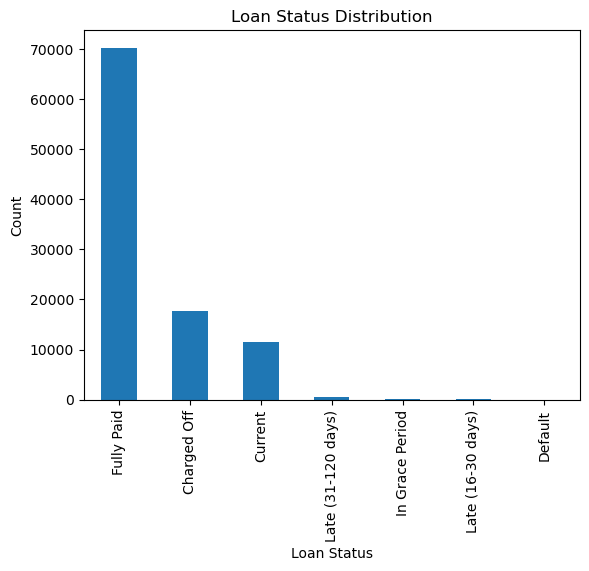

In [13]:
import matplotlib.pyplot as plt

df['loan_status'].value_counts().plot(kind='bar')

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

Most loans fall under Fully Paid status, while Charged Off loans are fewer. This suggests the dataset contains more successful loans than defaults.

In [14]:
df['loan_status'].value_counts()

loan_status
Fully Paid            70288
Charged Off           17603
Current               11402
Late (31-120 days)      441
In Grace Period         199
Late (16-30 days)        66
Default                   1
Name: count, dtype: int64

### Insight:
Most loans in the dataset are classified as "Fully Paid", indicating successful loan repayment. A smaller portion of loans are "Charged Off", which may represent defaults or failed repayments. The dataset appears imbalanced because successful loans significantly outnumber problematic loans.

In [15]:
df['loan_status'].value_counts()

loan_status
Fully Paid            70288
Charged Off           17603
Current               11402
Late (31-120 days)      441
In Grace Period         199
Late (16-30 days)        66
Default                   1
Name: count, dtype: int64

In [16]:
df['loan_risk'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

In [17]:
df['loan_risk'].value_counts()

loan_risk
0    82397
1    17603
Name: count, dtype: int64

### Insight:
The dataset is imbalanced, with a significantly higher number of non-default (good) loans compared to default (charged off) loans. This imbalance is common in financial datasets and should be considered when interpreting results, as it may influence model bias and analysis outcomes.

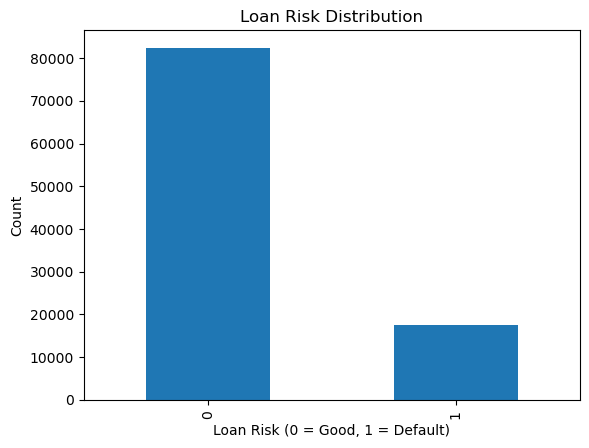

In [18]:
df['loan_risk'].value_counts().plot(kind='bar')

plt.title('Loan Risk Distribution')
plt.xlabel('Loan Risk (0 = Good, 1 = Default)')
plt.ylabel('Count')

plt.show()

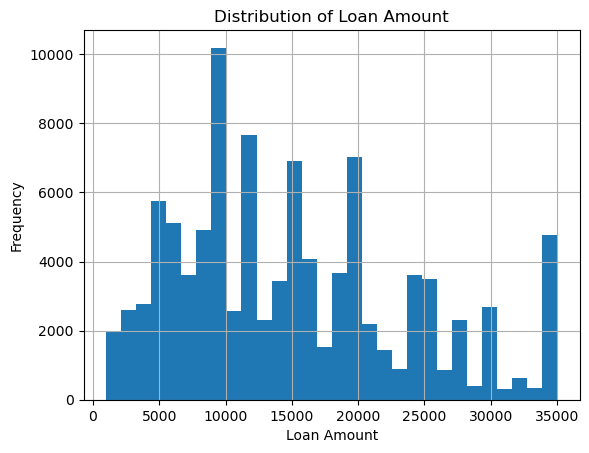

In [19]:
df['loan_amnt'].hist(bins=30)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

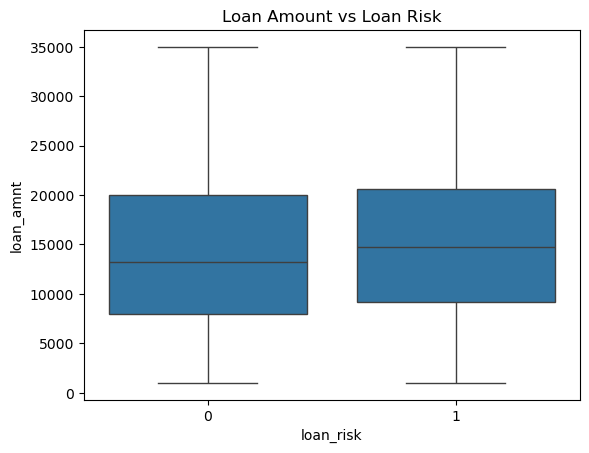

In [20]:
import seaborn as sns

sns.boxplot(x='loan_risk', y='loan_amnt', data=df)

plt.title('Loan Amount vs Loan Risk')
plt.show()

### Insight:
This boxplot helps compare loan amounts between default and non-default borrowers. Differences in median or spread may indicate whether loan size is a factor influencing default risk.

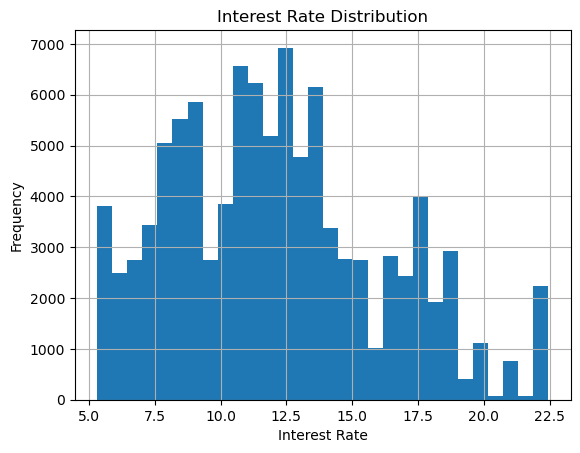

In [21]:
df['int_rate'].hist(bins=30)

plt.title('Interest Rate Distribution')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')

plt.show()

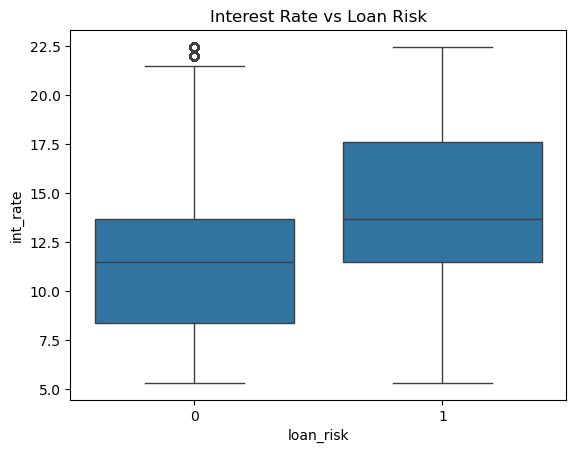

In [22]:
sns.boxplot(x='loan_risk', y='int_rate', data=df)

plt.title('Interest Rate vs Loan Risk')
plt.show()

### Insight:
This analysis shows the relationship between interest rate and loan default risk. Higher interest rates may indicate higher perceived borrower risk, and differences between groups can suggest a strong relationship between interest rate and default probability.

In [23]:
df['grade'].value_counts()

grade
B    30772
C    29198
A    17493
D    13344
E     6951
F     1849
G      393
Name: count, dtype: int64

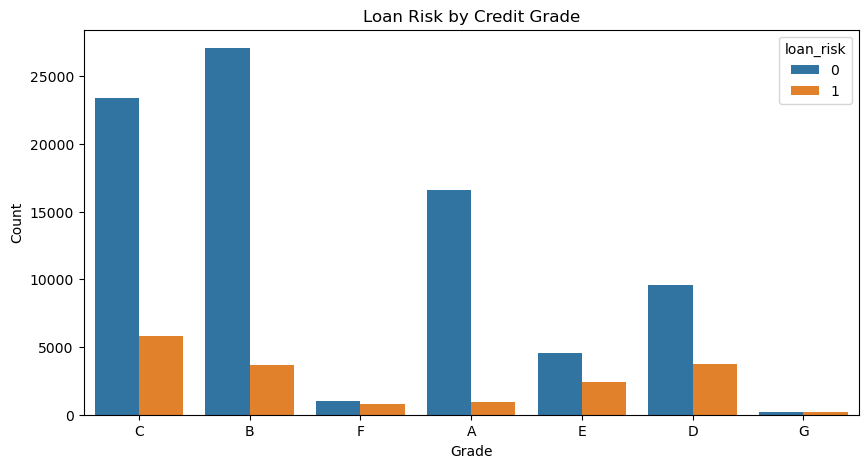

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(x='grade', hue='loan_risk', data=df)

plt.title('Loan Risk by Credit Grade')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.show()

### Insight:
Credit grade shows a strong relationship with loan default risk. Lower credit grades tend to have a higher proportion of defaults, while higher grades are associated with more reliable borrowers. This suggests credit grading is a strong predictor of loan performance.

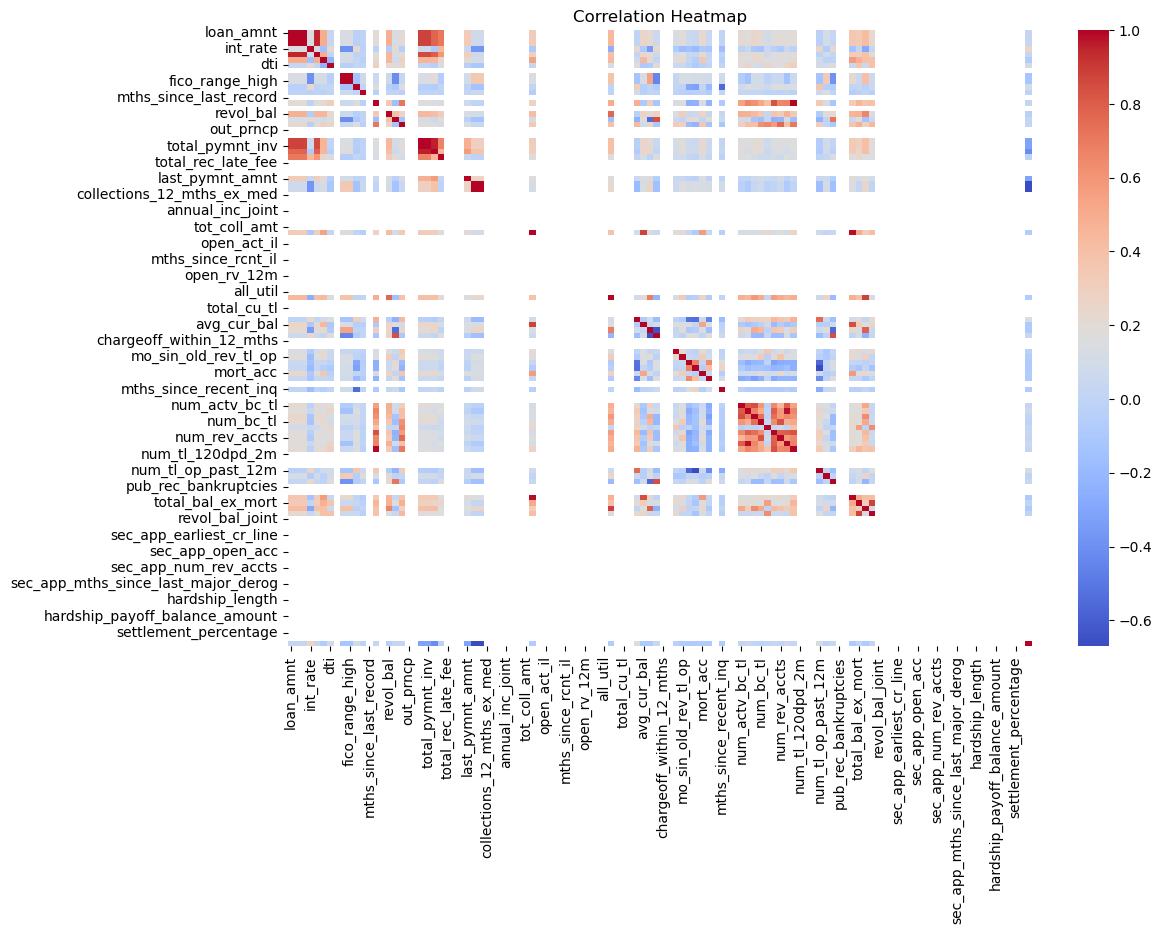

In [26]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), 
            annot=False, 
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [27]:
df.corr(numeric_only=True)['loan_risk'].sort_values(ascending=False)

loan_risk                         1.000000
int_rate                          0.254289
acc_open_past_24mths              0.140378
num_tl_op_past_12m                0.120498
inq_last_6mths                    0.096606
                                    ...   
hardship_payoff_balance_amount         NaN
hardship_last_payment_amount           NaN
settlement_amount                      NaN
settlement_percentage                  NaN
settlement_term                        NaN
Name: loan_risk, Length: 114, dtype: float64

### Insight:
Correlation analysis helps identify which numeric features are most strongly associated with loan default risk. Features with higher absolute correlation values may be more useful for predicting borrower risk.

### Insight:
Correlation analysis shows that interest rate has the strongest relationship with loan default risk, suggesting that higher-risk borrowers tend to be charged higher interest rates. Other credit activity features such as recent inquiries and account openings show weaker positive relationships with default risk. Several hardship and settlement-related variables are not usable in correlation analysis due to missing or non-numeric values.

# Exploratory Data Analysis (Final Summary)

### Key Findings:

- The dataset is highly imbalanced, with significantly more non-default loans than default loans.
- Interest rate shows the strongest positive relationship with loan default risk.
- Borrowers with higher credit activity (more recent inquiries and account openings) tend to have slightly higher default risk.
- Loan amount shows limited separation between default and non-default groups.
- Credit grade is an important indicator, with lower grades associated with higher default rates.

### Most Important Features:

Based on correlation and visual analysis, the most important features influencing loan default risk are:
- Interest rate (int_rate)
- Credit grade (grade)
- Recent credit inquiries (inq_last_6mths)
- Account activity metrics (acc_open_past_24mths, num_tl_op_past_12m)

These features show meaningful relationships with the target variable (loan_risk).

### Business Insight:

The analysis suggests that lending risk is primarily driven by borrower credit quality and pricing strategy. Higher interest rates are associated with higher default risk, indicating lenders already price risk into loan terms. Credit behavior indicators such as recent inquiries and credit activity also provide useful signals for identifying risky borrowers. These insights can help financial institutions improve risk assessment and lending decisions.

In [5]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [6]:
df['loan_status'].value_counts()

loan_status
Fully Paid            70288
Charged Off           17603
Current               11402
Late (31-120 days)      441
In Grace Period         199
Late (16-30 days)        66
Default                   1
Name: count, dtype: int64

In [7]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

df['loan_status'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

df['loan_status'].value_counts()

loan_status
0    70288
1    17603
Name: count, dtype: int64

In [9]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [11]:
drop_cols = ['id', 'member_id']
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

In [16]:
#categorical_cols = X.select_dtypes(include=['object']).columns

#X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Attempted full one-hot encoding caused memory error due to high-cardinality categorical variables. This was resolved by dropping high-unique-value columns before encoding.

In [13]:
X.select_dtypes(include=['object']).nunique().sort_values(ascending=False)

url                          87891
emp_title                    33659
zip_code                       878
earliest_cr_line               619
addr_state                      49
last_pymnt_d                    42
last_credit_pull_d              42
settlement_date                 35
sub_grade                       35
debt_settlement_flag_date       33
hardship_end_date               23
payment_plan_start_date         22
hardship_start_date             22
title                           13
purpose                         12
emp_length                      11
hardship_reason                  9
desc                             7
grade                            7
hardship_loan_status             4
home_ownership                   4
issue_d                          3
settlement_status                3
verification_status              3
application_type                 2
debt_settlement_flag             2
hardship_status                  2
initial_list_status              2
term                

In [14]:
X = X.drop(columns=[
    'url',
    'emp_title',
    'zip_code',
    'desc'
], errors='ignore')

In [15]:
categorical_cols = X.select_dtypes(include=['object']).columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(61523, 1089) (26368, 1089)
(61523,) (26368,)


In [19]:
X_train.isnull().sum().sort_values(ascending=False).head(20)

sec_app_fico_range_low                        61523
sec_app_mths_since_last_major_derog           61523
revol_bal_joint                               61523
sec_app_earliest_cr_line                      61523
sec_app_inq_last_6mths                        61523
sec_app_mort_acc                              61523
sec_app_open_acc                              61523
sec_app_revol_util                            61523
sec_app_open_act_il                           61523
sec_app_num_rev_accts                         61523
sec_app_chargeoff_within_12_mths              61523
sec_app_collections_12_mths_ex_med            61523
sec_app_fico_range_high                       61523
orig_projected_additional_accrued_interest    61275
dti_joint                                     61244
annual_inc_joint                              61243
hardship_length                               61168
hardship_dpd                                  61168
hardship_amount                               61168
deferral_ter

In [20]:
np.isinf(X_train).sum().sort_values(ascending=False).head(20)

loan_amnt                    0
earliest_cr_line_Nov-1982    0
earliest_cr_line_Nov-1988    0
earliest_cr_line_Nov-1987    0
earliest_cr_line_Nov-1986    0
earliest_cr_line_Nov-1985    0
earliest_cr_line_Nov-1984    0
earliest_cr_line_Nov-1983    0
earliest_cr_line_Nov-1981    0
earliest_cr_line_Jul-2006    0
earliest_cr_line_Nov-1980    0
earliest_cr_line_Nov-1979    0
earliest_cr_line_Nov-1978    0
earliest_cr_line_Nov-1977    0
earliest_cr_line_Nov-1976    0
earliest_cr_line_Nov-1975    0
earliest_cr_line_Nov-1989    0
earliest_cr_line_Nov-1990    0
earliest_cr_line_Nov-1991    0
earliest_cr_line_Nov-1992    0
dtype: int64

In [22]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [23]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(61523, 1089)
(26368, 1089)


Preprocessing Summary

In this step, the dataset was prepared for machine learning. Categorical variables were converted into numeric form using one-hot encoding, and high-cardinality features were removed to avoid creating an overly large feature set. The data was then split into training and testing sets so the model could be evaluated on unseen data. Finally, numerical features were standardized so that all variables are on a similar scale and contribute fairly to the model.

In [25]:
print("Capstone 2 preprocessing complete")

Capstone 2 preprocessing complete
